In [16]:
# PROJETO DE INTELIGÊNCIA ARTIFICIAL
# COMITÊ DE CLASSIFICADORES - NFL

# Objetivo:
# Desenvolver um Comitê de Classificadores capaz de
# prever se a proxima jogada com base na media de probabilidade das outras seria próxima à End Zone
# adversária utilizando dados de rastreamento dos
# jogadores da NFL.

# Para isso, utilizamos informações de posição,
# velocidade e aceleração dos jogadores e combinamos
# os algoritmos KNN, Árvore de Decisão e Naive Bayes
# por meio de um Voting Classifier.

# VARIÁVEIS UTILIZADAS:
# x -> posição horizontal do jogador em campo
# y -> posição vertical do jogador em campo
# s -> velocidade do jogador
# a -> aceleração do jogador

# Essas variáveis são utilizadas como entrada para
# os modelos de Machine Learning.

# A variável alvo considera:
# 0 = Jogada distante da End Zone
# 1 = Jogada próxima da End Zone

# Consideramos próximas as jogadas realizadas após
# a linha de métrica 80 do campo.

In [17]:
#input inicial para a case de dados.
from google.colab import files
files.upload()

import pandas as pd
df = pd.read_csv('input_2023_w12.csv')
df.head(294942)

Saving input_2023_w12.csv to input_2023_w12 (1).csv


,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,player_role,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
0,2023112300,55,False,44888,1,left,85,Alex Anzalone,6-3,240,...,Defensive Coverage,80.52,22.92,0.67,1.82,179.67,94.48,31,36.430000,31.020000
1,2023112300,55,False,44888,2,left,85,Alex Anzalone,6-3,240,...,Defensive Coverage,80.53,22.81,1.04,2.33,175.08,96.24,31,36.430000,31.020000
2,2023112300,55,False,44888,3,left,85,Alex Anzalone,6-3,240,...,Defensive Coverage,80.54,22.69,1.31,2.41,173.87,96.24,31,36.430000,31.020000
3,2023112300,55,False,44888,4,left,85,Alex Anzalone,6-3,240,...,Defensive Coverage,80.57,22.54,1.66,2.59,170.28,97.27,31,36.430000,31.020000
4,2023112300,55,False,44888,5,left,85,Alex Anzalone,6-3,240,...,Defensive Coverage,80.62,22.34,2.04,2.75,166.20,99.95,31,36.430000,31.020000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294935,2023112700,3988,True,52584,46,right,44,K.J. Osborn,6-0,200,...,Targeted Receiver,55.54,25.08,1.04,4.69,74.31,279.72,11,55.470001,25.389999
294936,2023112700,3988,True,52584,47,right,44,K.J. Osborn,6-0,200,...,Targeted Receiver,55.63,25.09,0.84,4.31,100.68,276.50,11,55.470001,25.389999
294937,2023112700,3988,True,52584,48,right,44,K.J. Osborn,6-0,200,...,Targeted Receiver,55.70,25.05,0.88,3.97,130.94,274.36,11,55.470001,25.389999
294938,2023112700,3988,True,52584,49,right,44,K.J. Osborn,6-0,200,...,Targeted Receiver,55.76,24.98,1.02,3.41,152.27,272.66,11,55.470001,25.389999


In [18]:
# TRATAMENTO DOS DADOS
# Preenchimento dos valores ausentes utilizando
# a média das variáveis numéricas.

# Variável alvo do modelo
# 1 = Jogada próxima da End Zone
# 0 = Jogada distante da End Zone
df = df.fillna(df.mean(numeric_only=True))

df['red_zone_play'] = (
    df['absolute_yardline_number'] > 80
).astype(int)

In [19]:
X = df[['x', 'y', 's', 'a']]
y = df['red_zone_play']

#---------------------------
# Distribuição das Classes

print("Distribuição das classes:")

print(
    df['red_zone_play']
    .value_counts()
)

from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2
)

Distribuição das classes:
red_zone_play
0    226565
1     68375
Name: count, dtype: int64


In [20]:
#treino individual KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_treino, y_treino)

KNeighborsClassifier()

In [21]:
#treino individual arvore de decisão
from sklearn.tree import DecisionTreeClassifier

arvore = DecisionTreeClassifier()

arvore.fit(X_treino, y_treino)

DecisionTreeClassifier()

In [22]:
#treino individual naive bayes
from sklearn.naive_bayes import GaussianNB

bayes = GaussianNB()

bayes.fit(X_treino, y_treino)

GaussianNB()

In [23]:
#COMITÊ
from sklearn.ensemble import VotingClassifier

comite = VotingClassifier(
    estimators=[
        ('knn', knn),
        ('arvore', arvore),
        ('bayes', bayes)
    ],
    voting='soft')

comite.fit(X_treino, y_treino)

VotingClassifier(estimators=[('knn', KNeighborsClassifier()),
                             ('arvore', DecisionTreeClassifier()),
                             ('bayes', GaussianNB())],
                 voting='soft')

In [24]:
# ACURÁCIA DOS MODELOS
from sklearn.metrics import accuracy_score

print("KNN:", accuracy_score(y_teste, knn.predict(X_teste)))

print("Árvore:", accuracy_score(y_teste, arvore.predict(X_teste)))

print("Bayes:", accuracy_score(y_teste, bayes.predict(X_teste)))

print("Comitê:", accuracy_score(y_teste, comite.predict(X_teste)))

KNN: 0.9362582220112565
Árvore: 0.9089814877602225
Bayes: 0.9025055943581746
Comitê: 0.9271885807282837


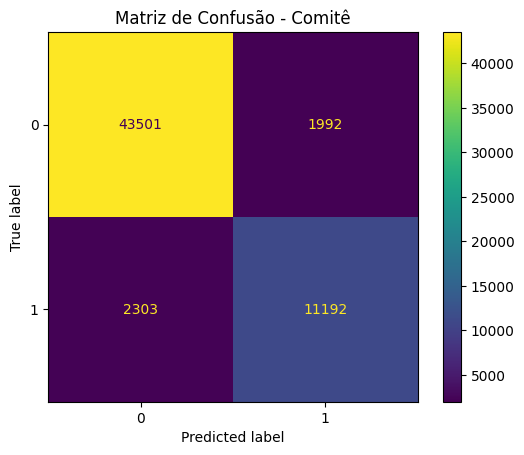

In [25]:
# MATRIZ DE CONFUSÃO
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predicoes = comite.predict(X_teste)

matriz = confusion_matrix(
    y_teste,
    predicoes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz
)

disp.plot()

plt.title("Matriz de Confusão - Comitê")

plt.show()

In [26]:
# PRECISION, RECALL E F1-SCORE
from sklearn.metrics import classification_report

print("Relatório de Classificação")

print(
    classification_report(
        y_teste,
        predicoes
    )
)

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.95      0.96      0.95     45493
           1       0.85      0.83      0.84     13495

    accuracy                           0.93     58988
   macro avg       0.90      0.89      0.90     58988
weighted avg       0.93      0.93      0.93     58988



COMPARAÇÃO DOS MODELOS

MODELO: KNN
Accuracy : 93.42 %
Precision: 86.27 %
Recall   : 85.34 %
F1-Score : 85.8 %
-----------------------------------
MODELO: Árvore
Accuracy : 90.9 %
Precision: 80.17 %
Recall   : 80.95 %
F1-Score : 80.56 %
-----------------------------------
MODELO: Bayes
Accuracy : 90.21 %
Precision: 78.42 %
Recall   : 79.99 %
F1-Score : 79.2 %
-----------------------------------
MODELO: Comitê
Accuracy : 92.67 %
Precision: 84.66 %
Recall   : 83.71 %
F1-Score : 84.18 %
-----------------------------------


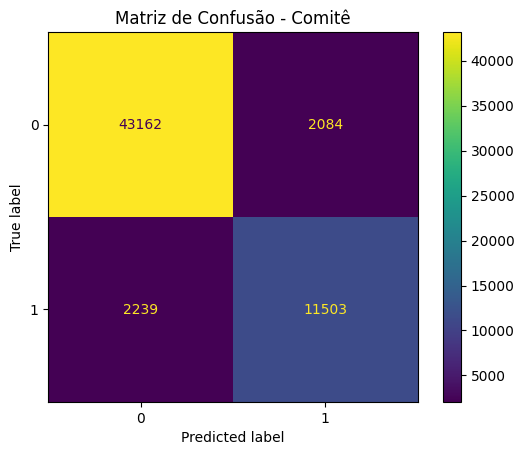


RELATÓRIO DE CLASSIFICAÇÃO

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     45246
           1       0.85      0.84      0.84     13742

    accuracy                           0.93     58988
   macro avg       0.90      0.90      0.90     58988
weighted avg       0.93      0.93      0.93     58988


PROBABILIDADE FINAL

Total de jogadas analisadas: 58988

Probabilidade média de NÃO estar perto da Endzone: 76.52 %
Probabilidade média de estar perto da Endzone: 23.48 %


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# COMPARAÇÃO DOS MODELOS
# ==========================================

modelos = {
    "KNN": knn,
    "Árvore": arvore,
    "Bayes": bayes,
    "Comitê": comite
}

print("====================================")
print("COMPARAÇÃO DOS MODELOS")
print("====================================\n")

for nome, modelo in modelos.items():

    predicoes = modelo.predict(X_teste)

    accuracy = accuracy_score(y_teste, predicoes) * 100
    precision = precision_score(y_teste, predicoes) * 100
    recall = recall_score(y_teste, predicoes) * 100
    f1 = f1_score(y_teste, predicoes) * 100

    print(f"MODELO: {nome}")
    print("Accuracy :", round(accuracy, 2), "%")
    print("Precision:", round(precision, 2), "%")
    print("Recall   :", round(recall, 2), "%")
    print("F1-Score :", round(f1, 2), "%")
    print("-" * 35)

# ==========================================
# MATRIZ DE CONFUSÃO
# ==========================================

predicoes = comite.predict(X_teste)

matriz = confusion_matrix(y_teste, predicoes)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz)

disp.plot()

plt.title("Matriz de Confusão - Comitê")

plt.show()

# ==========================================
# RELATÓRIO DE CLASSIFICAÇÃO
# ==========================================

print("\n====================================")
print("RELATÓRIO DE CLASSIFICAÇÃO")
print("====================================\n")

print(classification_report(y_teste, predicoes))

# ==========================================
# PROBABILIDADE FINAL
# ==========================================

probabilidades = comite.predict_proba(X_teste)

prob_nao_endzone = probabilidades[:, 0].mean() * 100
prob_endzone = probabilidades[:, 1].mean() * 100

total_jogadas = len(X_teste)

print("\n====================================")
print("PROBABILIDADE FINAL")
print("====================================\n")

print("Total de jogadas analisadas:", total_jogadas)

print("\nProbabilidade média de NÃO estar perto da Endzone:",
      round(prob_nao_endzone, 2), "%")

print("Probabilidade média de estar perto da Endzone:",
      round(prob_endzone, 2), "%")